# EDA Calendar Airbnb Málaga (2025–2026)  

## Datos de `calendar.csv`

Este dataset tiene la información de la ocupación de airbnb por fechar. A continuación describo las variables agrupadas por categorías.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

In [2]:
# Estilo visual uniforme
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})
ACCENT = '#E8504A'   # rojo Airbnb
BLUE   = '#3A86FF'
GREEN  = '#2DC653'

## 1. Carga y preparación de datos

In [3]:
calendar = pd.read_csv('../data/calendar.csv')
print(calendar.shape)
calendar.head()

(3545610, 7)


,listing_id,date,available,price,adjusted_price,minimum_nights,maximum_nights
0,6341180,2025-09-30,t,NaN,NaN,2,1125
1,6341180,2025-10-01,f,NaN,NaN,2,1125
2,6341180,2025-10-02,f,NaN,NaN,2,1125
3,6341180,2025-10-03,f,NaN,NaN,2,1125
4,6341180,2025-10-04,f,NaN,NaN,2,1125


In [4]:
calendar['listing_id'].nunique()
((calendar['listing_id'].value_counts())== 365).all()


np.True_

In [5]:
calendar.dtypes

listing_id          int64
date                  str
available             str
price             float64
adjusted_price    float64
minimum_nights      int64
maximum_nights      int64
dtype: object

## 2. Ingeniería de características y EDA

Como podemos ver, las variables de `date` y `available`, ya que `date` tiene que estar en datetime y `available` en bool. Por otro lado, podemos observar que las variables de `price` y `adjusted_price` tienen valores nulos.

In [6]:
calendar['date'] = pd.to_datetime(calendar['date'])
calendar['available'] = calendar['available'].map({'t': True, 'f': False})

In [7]:
# Miramos cuantos valores nulos tienen estas dos variables.
price_null = calendar['price'].isnull().sum()
adjusted_price_null = calendar['adjusted_price'].isnull().sum()
print(price_null, adjusted_price_null, calendar.shape[0])

3545610 3545610 3545610


Como podemos ver el número de valores nulos de ambas variables es igual al número de observaciones que hay en los datos. Por lo que como son variables irrelevantes, podemos eliminar esas variables.

In [8]:
calendar.drop(columns=['price', 'adjusted_price'], inplace=True)
calendar.head()

,listing_id,date,available,minimum_nights,maximum_nights
0,6341180,2025-09-30,True,2,1125
1,6341180,2025-10-01,False,2,1125
2,6341180,2025-10-02,False,2,1125
3,6341180,2025-10-03,False,2,1125
4,6341180,2025-10-04,False,2,1125


### 2.1 Ocupación por fecha

Despues de ver las características, vamos a crear una variable nueva que almacene el evento que hay en cada fecha para poder ver si hay una relación entre el número de ocupación de aribnb y los eventos y fiestas de malaga y madrid. También, vamos a crear una variable booked para ver si un apartamento/casa está reservado o no.

In [9]:
def get_event(date):
    if pd.Timestamp('2026-08-15') <= date <= pd.Timestamp('2026-08-22'): return 'Feria de Málaga'
    if pd.Timestamp('2026-03-29') <= date <= pd.Timestamp('2026-04-05'): return 'Semana Santa'
    if (date.month == 11 and date.day >= 20) or (date.month == 1 and date.day <= 6): return 'Navidad/Reyes'
    if pd.Timestamp('2026-06-23') == date: return 'Noche de San Juan'
    if date.month in [6, 7, 8]: return 'Verano'
    return 'Temporada normal'

calendar['event'] = calendar['date'].apply(get_event)
calendar['booked'] = ~calendar['available']
calendar.head()

,listing_id,date,available,minimum_nights,maximum_nights,event,booked
0,6341180,2025-09-30,True,2,1125,Temporada normal,False
1,6341180,2025-10-01,False,2,1125,Temporada normal,True
2,6341180,2025-10-02,False,2,1125,Temporada normal,True
3,6341180,2025-10-03,False,2,1125,Temporada normal,True
4,6341180,2025-10-04,False,2,1125,Temporada normal,True


Ahora, vamos a ver está información gráficamente.

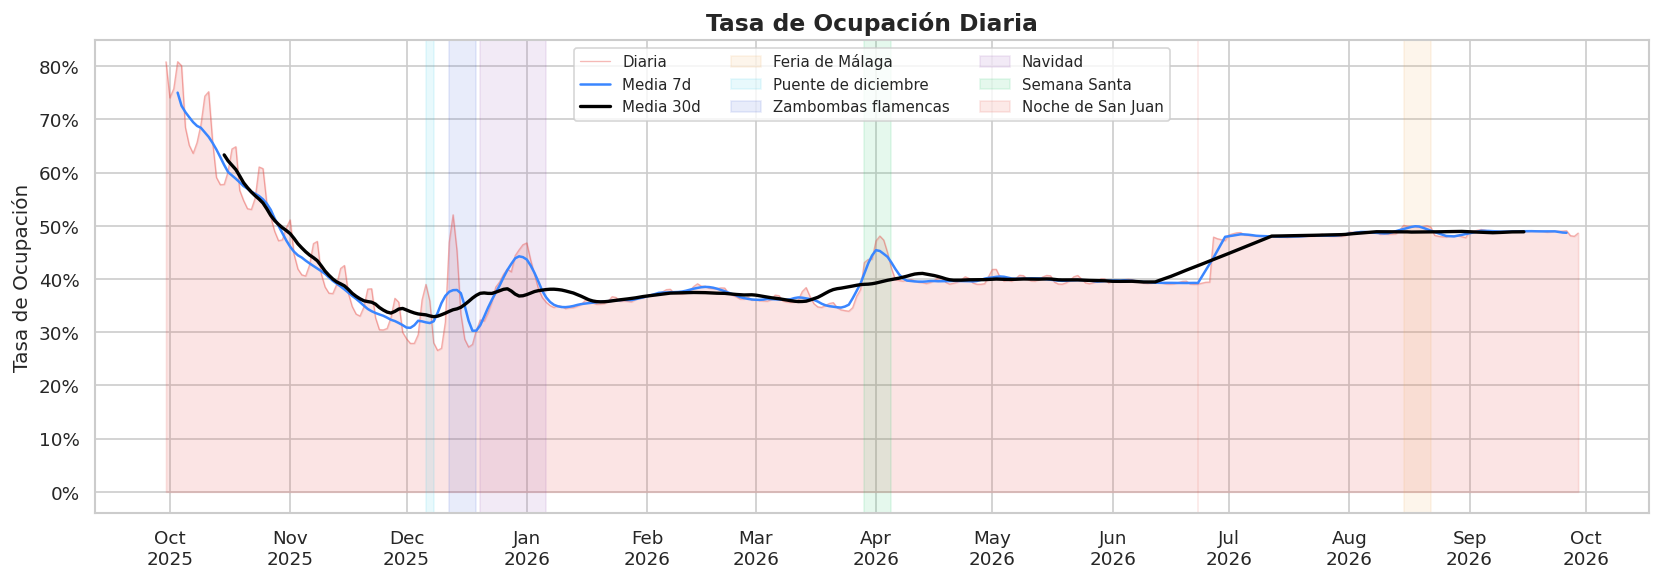

In [10]:
daily_occ = calendar.groupby('date')['booked'].mean()
daily_occ_7d  = daily_occ.rolling(7,  center=True).mean()
daily_occ_30d = daily_occ.rolling(30, center=True).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(daily_occ.index, daily_occ, alpha=0.15, color=ACCENT)
ax.plot(daily_occ.index, daily_occ,      color=ACCENT,  alpha=0.4, lw=0.8, label='Diaria')
ax.plot(daily_occ_7d.index,  daily_occ_7d,  color=BLUE,   lw=1.5,  label='Media 7d')
ax.plot(daily_occ_30d.index, daily_occ_30d, color='black', lw=2,    label='Media 30d')

# Marcar eventos
events = [
    ('2026-08-15', '2026-08-22', 'Feria de Málaga', "#F1B060"),
    ('2025-12-6', '2025-12-8', 'Puente de diciembre', "#45CFEB"),
    ('2025-12-12', '2025-12-19', 'Zambombas flamencas', "#4863DA"),
    ('2025-12-20', '2026-01-06', 'Navidad', '#9B59B6'),
    ('2026-03-29', '2026-04-05', 'Semana Santa', '#2ECC71'),
    ('2026-06-23', '2026-06-23', 'Noche de San Juan', '#E74C3C')
]
for start, end, label, color in events:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.12, color=color, label=label)

ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.set_title('Tasa de Ocupación Diaria', fontsize=14, fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('Tasa de Ocupación')
ax.legend(ncol=3, fontsize=9)
plt.tight_layout()
plt.show()

El gráfico muestra una estacionalidad muy marcada, con una diferencia de casi 45 puntos porcentuales entre el pico de octubre (80%) y el valle que se puede apreciar de dicembre. Durante los meses de invierno, la ocupación se mantiene por debajo del 40%, con ligeros repuntes puntuales coincidiendo con eventos locales como las Zambombas flamencas o el Puente de diciembre, aunque su impacto es moderado. A partir abril, la Semana Santa impulsa una primera recuperación, y el verano consolida una ocupación estable en torno al 50%. También se puede ver que las fechas a partir del día de hoy son lo que la gente ya ha reservado, no es lo real, ya que todavía no ha pasado la fecha, por lo que se podría intentar estimar cual es el resultado esperado en esos meses.

La media de 30 días confirma que el mercado sigue un patron predecible y estacional, sin grandes sorpresas. Despues de ver la ocupación por día, vamos a proceder a ver la ocupación de airbnb por mes. Para ello, vamos a cread 2 variables que almacenen el mes de cada reserva.

### 2.2 Ocupación por mes

/tmp/ipykernel_11039/777528045.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=monthly, x='month_label', y='booked', order=month_order,


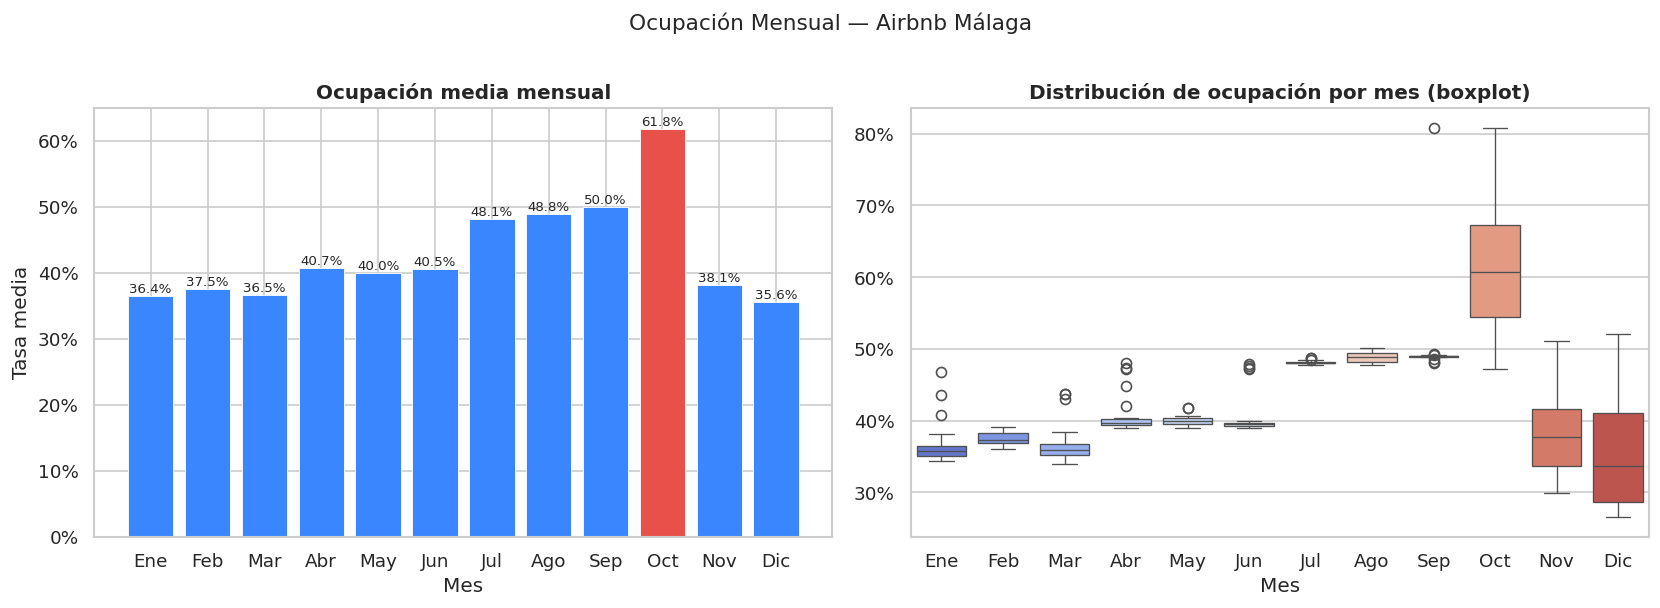

In [11]:
calendar['month'] = calendar['date'].dt.month
monthly = calendar.groupby(['date', 'month'])['booked'].mean().reset_index()
monthly_mean = monthly.groupby('month')['booked'].mean().reset_index()

month_labels = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
monthly['month_label'] = monthly['month'].apply(lambda m: month_labels[m-1])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Barras de media
colors = [ACCENT if v == monthly_mean['booked'].max() else BLUE for v in monthly_mean['booked']]
ax1.bar(month_labels, monthly_mean['booked'], color=colors, edgecolor='white', linewidth=0.5)
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax1.set_title('Ocupación media mensual', fontweight='bold')
ax1.set_xlabel('Mes'); ax1.set_ylabel('Tasa media')
for i, v in enumerate(monthly_mean['booked']):
    ax1.text(i, v + 0.005, f'{v:.1%}', ha='center', fontsize=8)

# Boxplot por mes
month_order = month_labels
sns.boxplot(data=monthly, x='month_label', y='booked', order=month_order,
            palette='coolwarm', ax=ax2, linewidth=0.8)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax2.set_title('Distribución de ocupación por mes (boxplot)', fontweight='bold')
ax2.set_xlabel('Mes'); ax2.set_ylabel('')

plt.suptitle('Ocupación Mensual — Airbnb Málaga', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Gráfico de barras**

El gráfico de barras muestra que octubre es el mes con mayor ocupación en Airbnb Málaga, alcanzando el 61,8%, muy por encima del resto. El gráfico permite identificar dos grupos diferenciados, tomando como referencia una tasa media del 40%:

- Temporada baja (enero, febrero, marzo, noviembre y diciembre): todos por debajo del 39%, con diciembre como el mes más flojo (35,6%). Enero y marzo presentan tasas muy similares entre sí.

- Temporada media-alta (abril a octubre): rango del 40–62%, con una progresión ascendente desde abril hasta septiembre (50%), lo que sugiere que el verano en Málaga llega tarde pero con fuerza.

La transición de septiembre a octubre —del 50% al 61,8%— es especialmente llamativa y puede indicar que el turismo en Málaga se intensifica justo cuando las temperaturas empiezan a descender en el resto de Europa.

**Boxplot**

El boxplot complementa al gráfico de barras añadiendo información sobre la variabilidad y fiabilidad de cada mes. Los meses de invierno (enero a junio) presentan cajas muy compactas, lo que indica que su ocupación es consistente y predecible de un año a otro. Julio y agosto destacan por ser los meses más estables y homogéneos de todo el año, con una dispersión mínima.

En el extremo opuesto, octubre muestra la caja más amplia del gráfico, con valores que oscilan entre el 50% y el 68%, y valores atípicos que alcanzan el 80%. Es el mes con mayor potencial, pero también el de mayor incertidumbre. Noviembre y diciembre presentan cajas grandes y asimétricas hacia abajo, con bigotes que descienden hasta el 25–28%, lo que los convierte en los meses con mayor riesgo de ocupación muy baja.

En definitiva, el boxplot revela que no todos los meses son igual de predecibles: mientras el verano ofrece estabilidad y seguridad, el otoño-invierno puede deparar tanto buenas como malas sorpresas.

### 2.3 Ocupación por semana

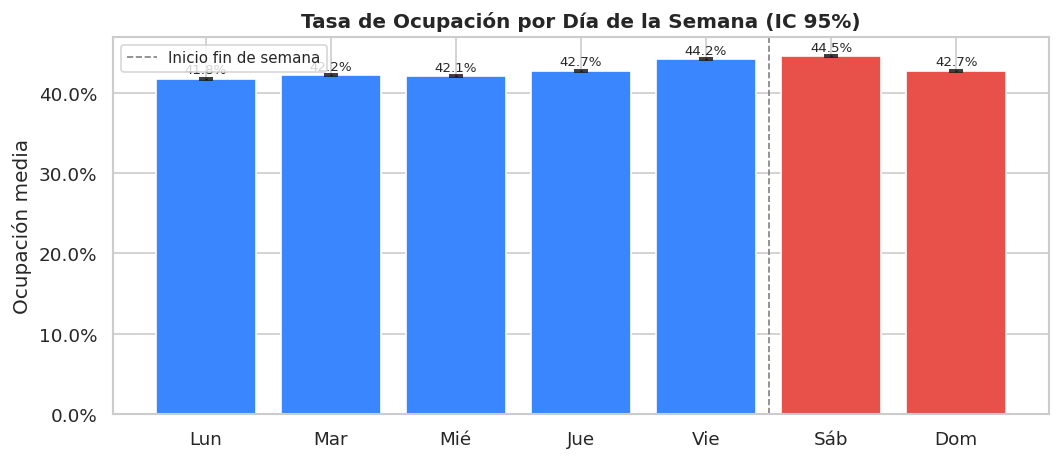

In [12]:
calendar['day_of_week'] = calendar['date'].dt.dayofweek
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_labels_es = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']

weekly_occ = (calendar.groupby('day_of_week')['booked']
              .agg(['mean','sem'])
              .reset_index()
              .sort_values('day_of_week'))

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(day_labels_es, weekly_occ['mean'],
               color=[ACCENT if x >= 5 else BLUE for x in weekly_occ['day_of_week']],
               yerr=weekly_occ['sem']*1.96, capsize=4, edgecolor='white')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_title('Tasa de Ocupación por Día de la Semana (IC 95%)', fontweight='bold')
ax.set_ylabel('Ocupación media')
ax.axvline(4.5, color='grey', linestyle='--', lw=1, label='Inicio fin de semana')
ax.legend(fontsize=9)
for bar, val in zip(bars, weekly_occ['mean']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.003, f'{val:.1%}',
            ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

Viendo este gráfico, hemos llegado a la conclusión de que la ocupación en Airbnb Málaga es sorprendentemente uniforme a lo largo de la semana, con todas las tasas comprendidas en un rango muy estrecho de tan solo 2,5 puntos porcentuales (del 42,0% al 44,5%). Esto contrasta con lo que cabría esperar en un destino turístico, donde normalmente el fin de semana concentra una demanda notablemente superior.

Lejos de eso, el sábado es el día de mayor ocupación (44,5%), seguido muy de cerca por el viernes (44,2%), mientras que el domingo cae hasta el 42,7%, igualando al jueves. Los días de entre semana muestran una progresión ligeramente ascendente de lunes a viernes, pero las diferencias son mínimas. Las barras de error del IC 95% son estrechas y consistentes en todos los días, lo que refuerza que estos valores son estadísticamente robustos y no producto de la casualidad.

En conjunto, estos datos sugieren que Málaga funciona como un destino de estancia prolongada más que de escapada de fin de semana: los visitantes no llegan y se van en dos días, sino que distribuyen sus noches de forma equilibrada a lo largo de toda la semana. Esto es una señal de madurez y diversificación del mercado turístico local.

In [13]:
# Test estadístico: ¿el fin de semana ocupa más?
calendar['is_weekend']  = calendar['day_of_week'].isin([5, 6]).astype(np.int8)
fds   = calendar[calendar['is_weekend']==1]['booked']
nofds = calendar[calendar['is_weekend']==0]['booked']
t, p  = stats.ttest_ind(fds, nofds)
print(f'\nTest t fin de semana vs. laborable: t={t:.3f}, p={p:.4f}')
print(f'Ocupación media Fin de semana: {fds.mean():.2%} | Laborable: {nofds.mean():.2%}')


Test t fin de semana vs. laborable: t=18.061, p=0.0000
Ocupación media Fin de semana: 43.63% | Laborable: 42.58%


El test t confirma que la diferencia de ocupación entre el fin de semana (43,63%) y los días laborables (42,58%) es estadísticamente significativa (t=18,06, p<0,0001). Sin embargo, esta significancia estadística no debe confundirse con relevancia práctica: la diferencia real entre ambos grupos es de apenas 1,05 puntos porcentuales.

Que un resultado sea estadísticamente significativo con un p-valor tan bajo se explica principalmente por el gran volumen de datos analizados, que permite detectar diferencias muy pequeñas con alta precisión. En términos de negocio, una diferencia de un punto porcentual en ocupación es prácticamente irrelevante y no justificaría, por ejemplo, una estrategia de precios diferenciada entre días laborables y fin de semana.

Esto refuerza la conclusión del gráfico anterior: Málaga es un destino de demanda distribuida y estable durante toda la semana, sin picos concentrados en el fin de semana. Para un propietario de Airbnb, esto es una buena noticia, ya que implica menos dependencia de los fines de semana y una ocupación más predecible y sostenida.

A continuación, profundizamos en el cruce entre ambas dimensiones analizadas —el mes y el día de la semana— a través de un mapa de calor que permite identificar, de forma visual e intuitiva, qué combinaciones concretas de mes y día concentran la mayor y menor ocupación.

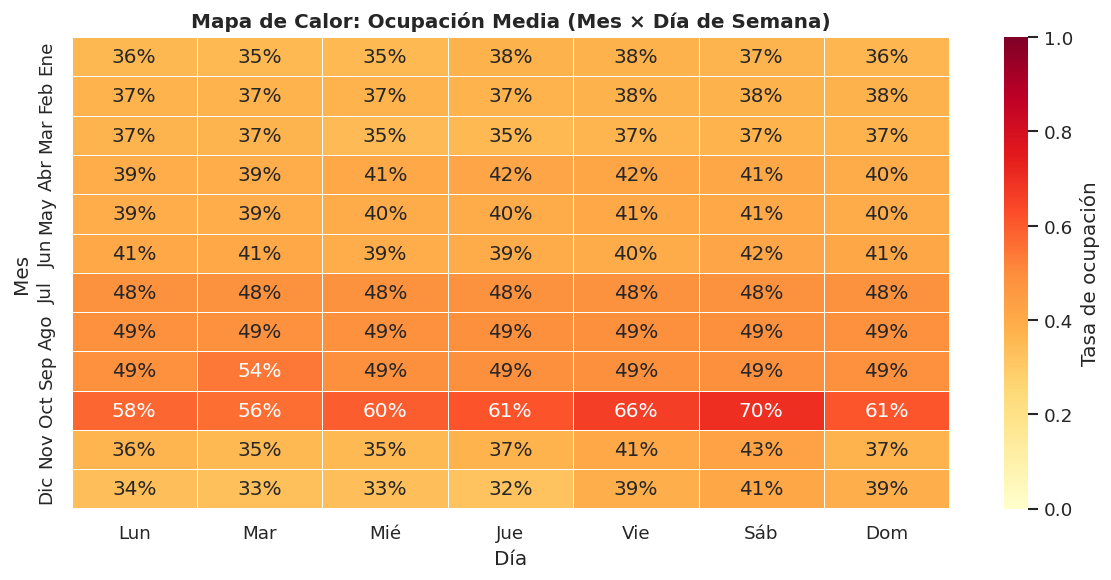

In [14]:
pivot = (calendar
         .groupby(['month', 'day_of_week'])['booked']
         .mean()
         .unstack('day_of_week'))
pivot.index = month_labels[:len(pivot)]
pivot.columns = day_labels_es

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='.0%', cmap='YlOrRd',
            linewidths=0.5, ax=ax, vmin=0, vmax=1,
            cbar_kws={'label': 'Tasa de ocupación'})
ax.set_title('Mapa de Calor: Ocupación Media (Mes × Día de Semana)', fontweight='bold')
ax.set_xlabel('Día'); ax.set_ylabel('Mes')
plt.tight_layout()
plt.show()

El mapa de calor confirma y matiza las conclusiones anteriores. El patrón más destacado es que octubre rompe con todo, siendo el único mes que presenta ocupaciones superiores al 55% en todos los días de la semana, con un pico máximo del 70% los sábados y valores que no bajan del 56% ningún día. Es una categoría aparte.

Para el resto de meses, se confirma la escasa influencia del día de la semana: julio, agosto y septiembre muestran filas prácticamente monocromáticas, con diferencias de apenas 1-2 puntos entre días, lo que refuerza la idea de una demanda completamente distribuida. Lo mismo ocurre en los meses de invierno, aunque en niveles mucho más bajos.

La única excepción parcial a esta uniformidad aparece en octubre y noviembre, donde el fin de semana —especialmente el sábado— sí genera una diferencia apreciable respecto a los días laborables, sugiriendo que en otoño el comportamiento del viajero se acerca más al perfil de escapada corta.

Diciembre destaca como el mes más débil en todos los días sin excepción, con mínimos del 32% los jueves, y es el único mes donde la ocupación cae por debajo del 35% de forma generalizada.
En resumen, el mes importa mucho más que el día de la semana a la hora de explicar la ocupación en Airbnb Málaga, salvo en otoño, donde ambas dimensiones empiezan a interactuar de forma más relevante.

### 2.4 Análisis de eventos espciales.

In [15]:
calendar['minimum_nights']  = calendar['minimum_nights'].astype(np.int32)
calendar['maximum_nights']  = calendar['maximum_nights'].astype(np.int32)
event_stats = (calendar
               .groupby('event')
               .agg(
                   ocupacion_media=('booked', 'mean'),
                   noches_min_media=('minimum_nights', 'mean'),
                   noches_max_media=('maximum_nights', 'mean'),
                   n_registros=('booked', 'count')
               )
               .sort_values('ocupacion_media', ascending=False))

display(event_stats.style.format({
    'ocupacion_media': '{:.1%}',
    'noches_min_media': '{:.1f}',
    'noches_max_media': '{:.1f}',
    'n_registros': '{:,}'
}).background_gradient(subset=['ocupacion_media'], cmap='YlOrRd'))

,ocupacion_media,noches_min_media,noches_max_media,n_registros
event,,,,
Feria de Málaga,49.9%,6.1,673.1,"77,712"
Verano,45.6%,5.8,662.1,"806,262"
Semana Santa,45.0%,5.5,666.2,"77,712"
Temporada normal,42.2%,5.2,654.5,"2,409,072"
Noche de San Juan,39.0%,5.2,658.1,"9,714"
Navidad/Reyes,36.0%,4.9,643.2,"165,138"


La tabla revela una jerarquía clara entre los distintos períodos del año. La Feria de Málaga lidera con una ocupación media del 49,9%, seguida del Verano (45,6%) y la Semana Santa (45,0%), los tres por encima de la temporada normal (42,2%). En el extremo opuesto, Navidad/Reyes es el período más débil con apenas un 36,0%, por debajo incluso de la temporada normal.

Un dato especialmente relevante es el de las noches mínimas exigidas: los eventos de mayor ocupación coinciden también con las estancias mínimas más altas, siendo la Feria de Málaga (6,1 noches) y el Verano (5,8 noches) los que más exigen. Esto sugiere que los propietarios endurecen sus condiciones precisamente cuando la demanda les da poder de negociación.

El volumen de registros confirma que la Temporada normal domina el conjunto del año con más de 2,4 millones de registros, lo que le otorga el mayor peso estadístico y convierte sus métricas en las más representativas del comportamiento habitual del mercado.

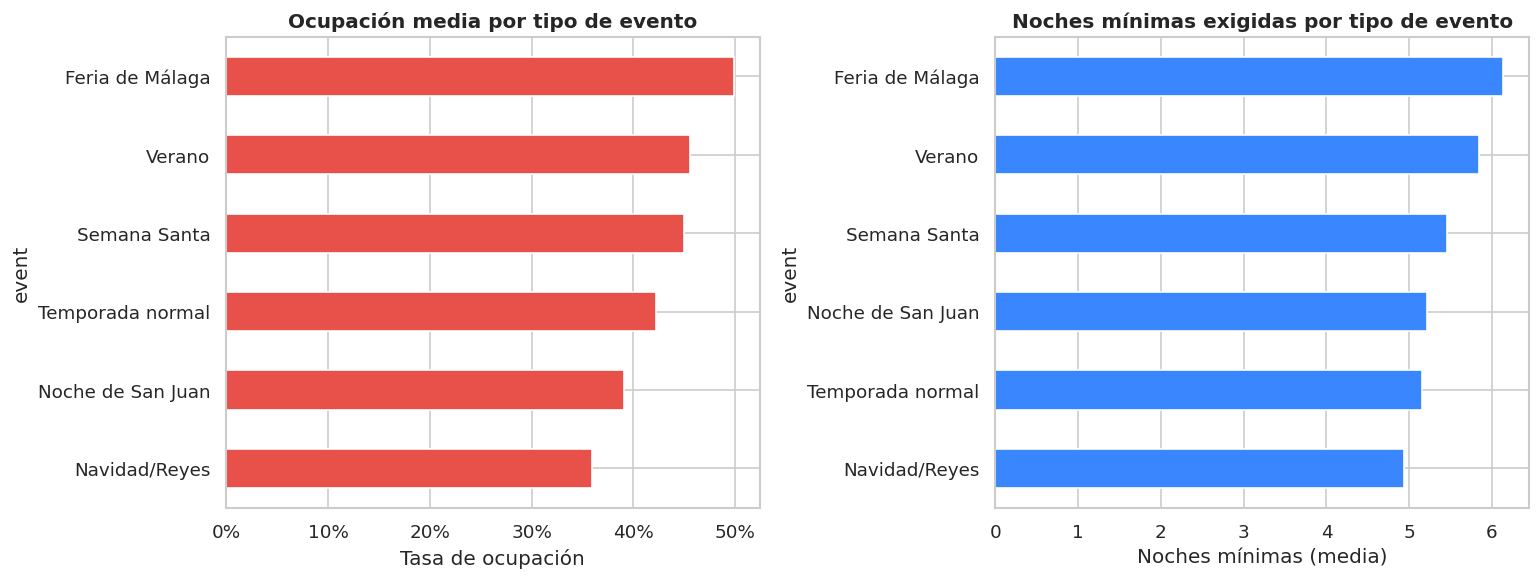

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Ocupación por evento
event_stats['ocupacion_media'].sort_values().plot(
    kind='barh', ax=axes[0], color=ACCENT, edgecolor='white')
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[0].set_title('Ocupación media por tipo de evento', fontweight='bold')
axes[0].set_xlabel('Tasa de ocupación')

# Noches mínimas por evento
event_stats['noches_min_media'].sort_values().plot(
    kind='barh', ax=axes[1], color=BLUE, edgecolor='white')
axes[1].set_title('Noches mínimas exigidas por tipo de evento', fontweight='bold')
axes[1].set_xlabel('Noches mínimas (media)')

plt.tight_layout()
plt.show()

Los dos gráficos de barras horizontales permiten visualizar de forma inmediata algo que no es casual: el ranking de ocupación y el de noches mínimas exigidas son prácticamente el mismo. Los eventos que generan más demanda —Feria de Málaga, Verano y Semana Santa— son exactamente los que imponen estancias mínimas más largas, mientras que Navidad/Reyes, con la ocupación más baja, es también donde los propietarios exigen menos noches.

Esto apunta a una estrategia activa de los anfitriones: en períodos de alta demanda, aprovechan su posición para filtrar reservas cortas y maximizar ingresos por estancia. La Noche de San Juan es la excepción más interesante — tiene una ocupación inferior a la temporada normal (39% vs 42,2%) pero exige más noches mínimas (5,2), lo que podría estar actuando como una barrera que limita su propia ocupación.

### 2.5 Distribución de noches mínimas y máximas.

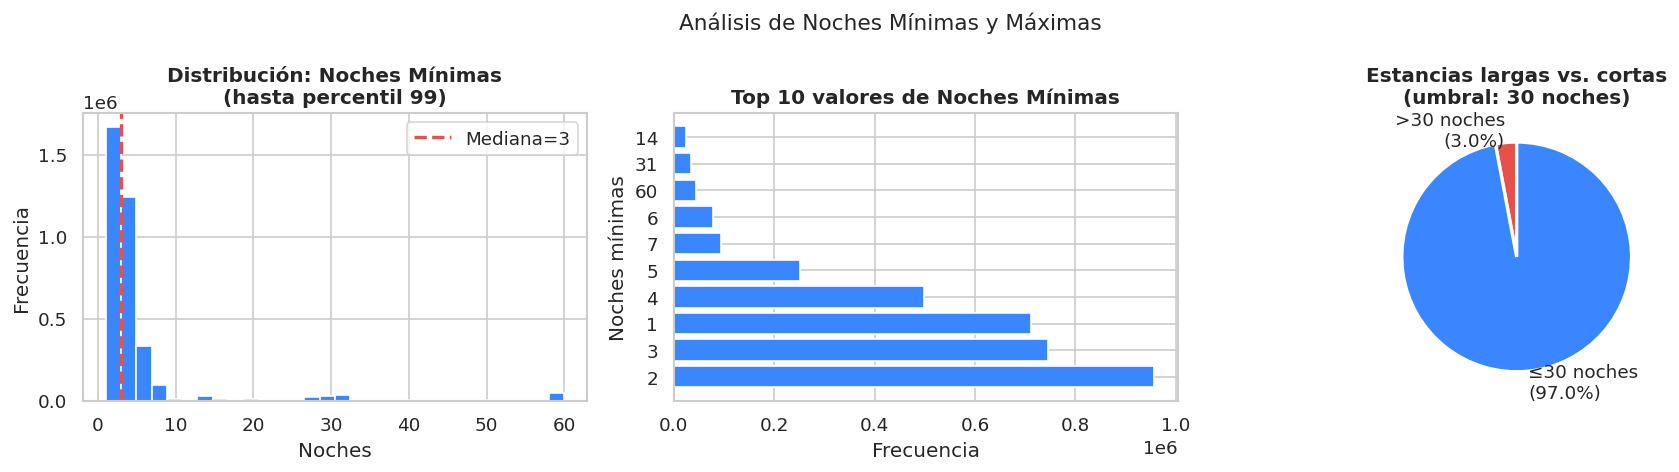

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histograma minimum_nights (cortado en p99)
p99_min = calendar['minimum_nights'].quantile(0.99)
data_min = calendar.loc[calendar['minimum_nights'] <= p99_min, 'minimum_nights']
axes[0].hist(data_min, bins=30, color=BLUE, edgecolor='white')
axes[0].set_title('Distribución: Noches Mínimas\n(hasta percentil 99)', fontweight='bold')
axes[0].set_xlabel('Noches'); axes[0].set_ylabel('Frecuencia')
axes[0].axvline(data_min.median(), color=ACCENT, lw=2, linestyle='--', label=f'Mediana={data_min.median():.0f}')
axes[0].legend()

# Top 10 valores de minimum_nights
top_min = calendar['minimum_nights'].value_counts().head(10)
axes[1].barh(top_min.index.astype(str), top_min.values, color=BLUE)
axes[1].set_title('Top 10 valores de Noches Mínimas', fontweight='bold')
axes[1].set_xlabel('Frecuencia'); axes[1].set_ylabel('Noches mínimas')

# Proporción de listings con minimum_nights > 30
pct_long = (calendar['minimum_nights'] > 30).mean()
axes[2].pie([pct_long, 1-pct_long],
            labels=[f'>30 noches\n({pct_long:.1%})', f'≤30 noches\n({1-pct_long:.1%})'],
            colors=[ACCENT, BLUE], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[2].set_title('Estancias largas vs. cortas\n(umbral: 30 noches)', fontweight='bold')

plt.suptitle('Análisis de Noches Mínimas y Máximas', fontsize=13)
plt.tight_layout()
plt.show()

Los tres gráficos dibujan un perfil muy claro del mercado, la inmensa mayoría de los alojamientos en Airbnb Málaga apuesta por estancias cortas. La distribución muestra una concentración máxima en las primeras noches, con una mediana de 3 noches y un Top 10 dominado por valores de 2 y 3 noches como los más frecuentes, seguidos de 1 y 4. El gráfico de tarta lo confirma de forma rotunda: el 97% de los registros exige 30 noches o menos, dejando las estancias largas como una categoría marginal del 3%.

La cola derecha del histograma, aunque visualmente pequeña, advierte de la existencia de valores extremos, llegando incluso hasta 60 noches en el percentil 99, que distorsionan la media hacia arriba sin representar el comportamiento habitual del mercado.

In [18]:
print('\nEstadísticas de minimum_nights:')
print(calendar['minimum_nights'].describe().to_string())
print(f'\nValores outlier (>365 noches): {(calendar["minimum_nights"] > 365).sum()}')


Estadísticas de minimum_nights:
count    3.545610e+06
mean     5.329076e+00
std      1.727365e+01
min      1.000000e+00
25%      2.000000e+00
50%      3.000000e+00
75%      4.000000e+00
max      5.000000e+02

Valores outlier (>365 noches): 365


Las estadísticas descriptivas matizan lo visto en los gráficos con precisión. Sobre un total de 3,5 millones de registros, la media de noches mínimas es de 5,3 noches, pero este valor está claramente inflado por valores extremos, el 75% de los registros exige 4 noches o menos, y la mediana se sitúa en apenas 3. La desviación típica de 17,3, muy elevada respecto a la media, confirma una distribución con una cola larga y pronunciada.

El valor máximo de 500 noches y la existencia de 365 registros con más de 365 noches mínimas exigidas son anomalías que probablemente corresponden a errores de configuración o alojamientos orientados al alquiler de larga duración, y deberían tratarse como outliers a la hora de interpretar el mercado vacacional. En definitiva, la mediana de 3 noches es el dato más representativo y útil para entender el comportamiento real del mercado.

### 2.6 Análisis por alojamiento.
#### 2.6.1 Distribución de tasa de ocupación individual.

In [19]:
listing_occ = (calendar
               .groupby('listing_id')['booked']
               .agg(['mean', 'count'])
               .rename(columns={'mean': 'ocupacion', 'count': 'dias_observados'}))

print(f'Total de listings únicos: {len(listing_occ):,}')
print(f'\nDistribución de ocupación individual:')
print(listing_occ['ocupacion'].describe().to_string())

Total de listings únicos: 9,714

Distribución de ocupación individual:
count    9714.000000
mean        0.428801
std         0.334157
min         0.000000
25%         0.112329
50%         0.350685
75%         0.753425
max         1.000000


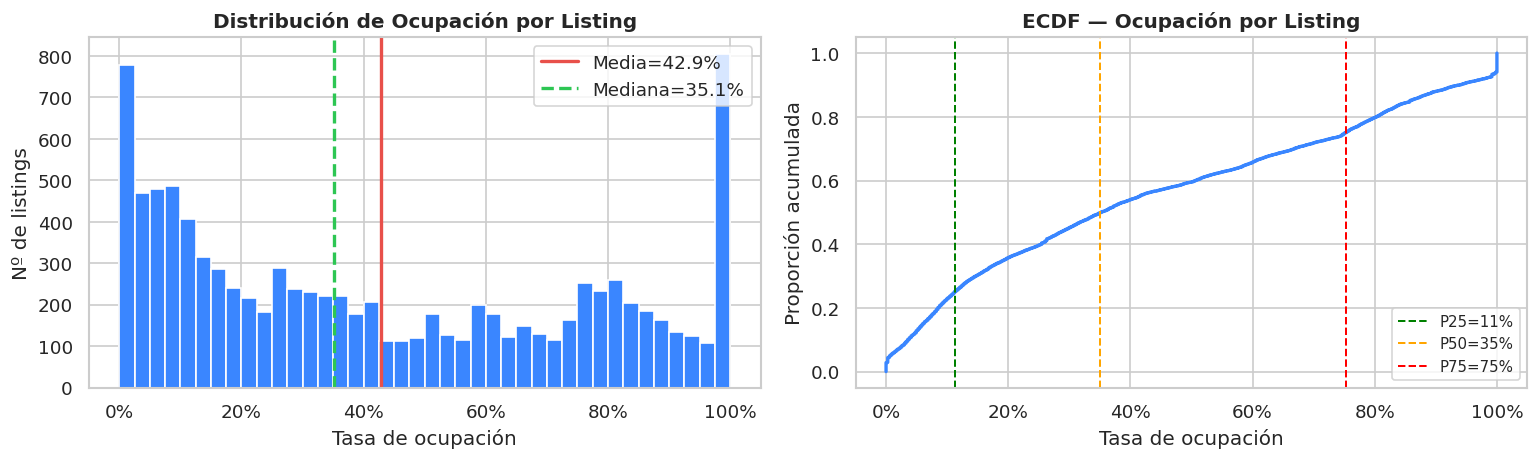

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma
axes[0].hist(listing_occ['ocupacion'], bins=40, color=BLUE, edgecolor='white')
axes[0].axvline(listing_occ['ocupacion'].mean(),   color=ACCENT, lw=2, linestyle='-',  label=f'Media={listing_occ["ocupacion"].mean():.1%}')
axes[0].axvline(listing_occ['ocupacion'].median(), color=GREEN,  lw=2, linestyle='--', label=f'Mediana={listing_occ["ocupacion"].median():.1%}')
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[0].set_title('Distribución de Ocupación por Listing', fontweight='bold')
axes[0].set_xlabel('Tasa de ocupación'); axes[0].set_ylabel('Nº de listings')
axes[0].legend()

# ECDF
sorted_occ = np.sort(listing_occ['ocupacion'])
ecdf = np.arange(1, len(sorted_occ)+1) / len(sorted_occ)
axes[1].plot(sorted_occ, ecdf, color=BLUE, lw=2)
for q, c in [(0.25, 'green'), (0.5, 'orange'), (0.75, 'red')]:
    val = np.quantile(sorted_occ, q)
    axes[1].axvline(val, color=c, linestyle='--', lw=1.2, label=f'P{int(q*100)}={val:.0%}')
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[1].set_title('ECDF — Ocupación por Listing', fontweight='bold')
axes[1].set_xlabel('Tasa de ocupación'); axes[1].set_ylabel('Proporción acumulada')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

Los dos gráficos revelan una realidad que las medias agregadas ocultaban, la ocupación individual de los listings es extremadamente heterogénea. El histograma muestra una distribución bimodal con dos picos claros, uno en tasas muy bajas (cerca del 0%) y otro en el 100%, lo que indica que el mercado está polarizado entre alojamientos que prácticamente no se reservan y alojamientos que están ocupados casi todo el año, con una meseta amplia de valores intermedios.

La brecha entre la media (42,9%) y la mediana (35,1%) confirma que una minoría de listings con ocupación muy alta tira de la media hacia arriba, distorsionando la imagen del mercado. La ECDF lo visualiza con claridad, el 25% de los listings no supera el 11% de ocupación, y hay que llegar al percentil 75 para encontrar tasas por encima del 75%. Dicho de otro modo, la mitad de los listings en Málaga tiene una ocupación inferior al 35%, lo que sugiere que muchos propietarios obtienen un rendimiento muy modesto de sus alojamientos.

#### 2.6.2 Segmentación de alojamientos por rendimiento.

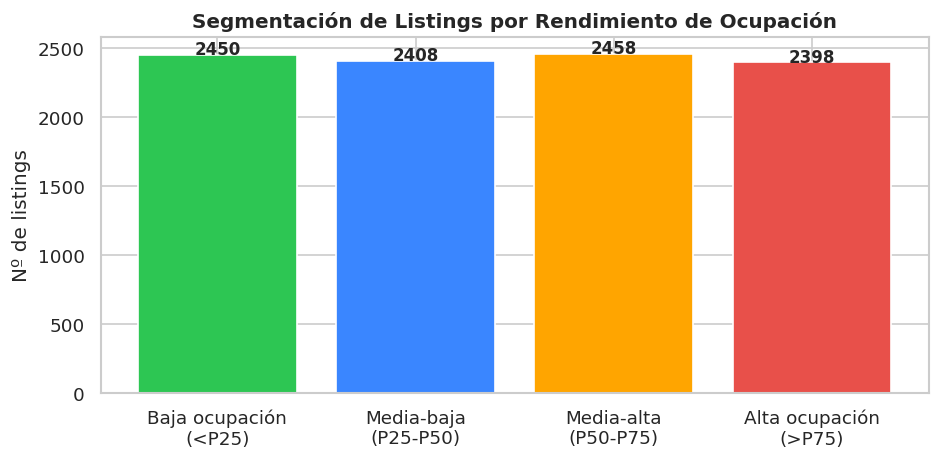

In [21]:
# Segmentamos en cuartiles
listing_occ['segmento'] = pd.qcut(
    listing_occ['ocupacion'], q=4,
    labels=['Baja ocupación\n(<P25)', 'Media-baja\n(P25-P50)',
            'Media-alta\n(P50-P75)', 'Alta ocupación\n(>P75)']
)

seg_counts = listing_occ['segmento'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(seg_counts.index.astype(str), seg_counts.values,
              color=[GREEN, BLUE, '#FFA500', ACCENT], edgecolor='white')
ax.set_title('Segmentación de Listings por Rendimiento de Ocupación', fontweight='bold')
ax.set_ylabel('Nº de listings')
for bar, val in zip(bars, seg_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 5, str(val),
            ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

Sobre un total de 9.714 listings únicos, las estadísticas confirman la dispersión extrema del mercado: con una desviación típica de 0,33 sobre una media de 0,43, los datos están muy alejados de una distribución homogénea. El rango va del 0% al 100% de ocupación, y la distancia entre el P25 (11%) y el P75 (75%) es de 64 puntos porcentuales, una amplitud enorme que refleja perfiles de propietario y estrategias muy distintas conviviendo en el mismo mercado.

El gráfico de segmentación, sin embargo, aporta un dato sorprendente, los cuatro cuartiles tienen un número de listings casi idéntico (2.400-2.458), lo que por definición es esperable en una segmentación por percentiles, pero lo relevante es que no hay un segmento dominante. El mercado no está concentrado en los extremos ni en el centro: está genuinamente repartido. Para un nuevo propietario, esto significa que entrar en el cuartil superior de ocupación es alcanzable, hay casi 2.400 listings que lo logran, pero también que caer en el cuartil inferior es un riesgo real para quien no gestione bien su alojamiento.

### 2.7 Correlación entre variables.

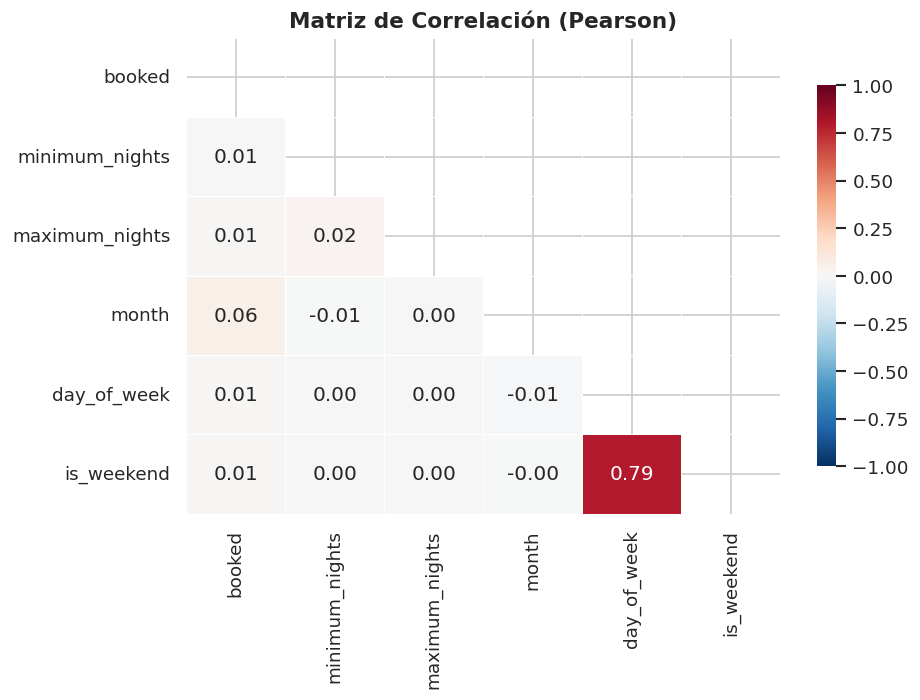

In [22]:
# Correlación de Pearson sobre variables numéricas
num_cols = ['booked', 'minimum_nights', 'maximum_nights', 'month', 'day_of_week', 'is_weekend']
corr_matrix = calendar[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Matriz de Correlación (Pearson)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

La matriz es contundente en su mensaje, ninguna de las variables analizadas tiene una correlación relevante con la ocupación (`booked`). Los valores oscilan entre 0,01 y 0,06, prácticamente cero en todos los casos, lo que indica que ni las noches mínimas, ni las máximas, ni el mes, ni el día de la semana explican por sí solos si un alojamiento está reservado o no en un día concreto.

La única correlación destacable de la matriz es la de 0,79 entre `day_of_week` e `is_weekend`, que es simplemente una correlación matemática trivial, el fin de semana está definido por el día de la semana, por lo que no aporta información nueva.

Dado que la correlación entre las variables es bastante bajo o nulo, podemos concluir que no hay relaciones lineales entre estas variables, por lo que su relación con la ocupación es no lineal o está mediada por otras variables que no hemos incluido en el este análisis. La estacionalidad, por ejemplo, ya demostramos que existe, pero actúa de forma compleja y no se captura bien con una correlación de Pearson simple.

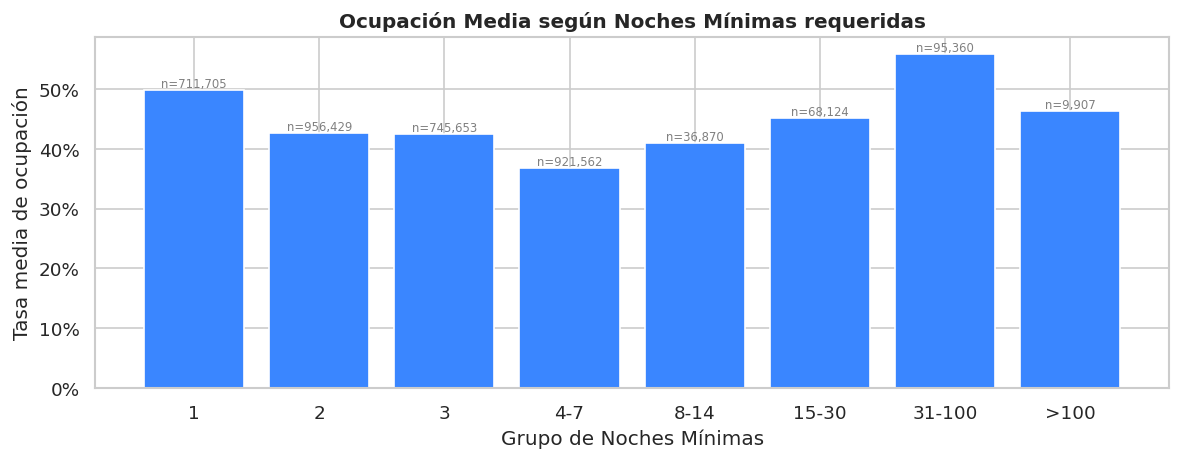

In [23]:
# ¿Afecta el minimum_nights a la probabilidad de estar reservado?
night_bins = [0, 1, 2, 3, 7, 14, 30, 100, 9999]
night_labels = ['1', '2', '3', '4-7', '8-14', '15-30', '31-100', '>100']
calendar['min_night_group'] = pd.cut(
    calendar['minimum_nights'], bins=night_bins, labels=night_labels
)

group_occ = (calendar
             .groupby('min_night_group')['booked']
             .agg(['mean', 'count'])
             .reset_index())

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(group_occ['min_night_group'].astype(str), group_occ['mean'],
              color=BLUE, edgecolor='white')
# Añadir N
for bar, n in zip(bars, group_occ['count']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'n={n:,}', ha='center', fontsize=7, color='grey')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_title('Ocupación Media según Noches Mínimas requeridas', fontweight='bold')
ax.set_xlabel('Grupo de Noches Mínimas'); ax.set_ylabel('Tasa media de ocupación')
plt.tight_layout()
plt.show()

El gráfico muestra un patrón que a primera vista parece contradictorio, exigir una sola noche genera la mayor ocupación media (50%), mientras que ampliar el mínimo a 4-7 noches la reduce al 37%, el nivel más bajo. Sin embargo, a partir de ahí la tendencia se invierte sorprendentemente, viendo que los alojamientos con mínimos de 31-100 noches alcanzan el 55% de ocupación, el máximo del gráfico.

Esto se explica por perfiles de alojamiento radicalmente distintos. Los de 1 noche capturan máxima demanda flexible. Los de 4-7 noches pierden viajeros de paso sin compensarlo con estancias largas, quedándose en tierra de nadie. Los de 31-100 noches corresponden a alquileres de media-larga duración con inquilinos estables, lo que garantiza una ocupación alta pero en un mercado diferente al vacacional.

La conclusión práctica es clara, los extremos funcionan mejor que el rango intermedio. Para un propietario vacacional, minimizar las noches mínimas maximiza la ocupación; solo tiene sentido elevarlas mucho si el modelo de negocio apunta al alquiler de media estancia.

### 2.8 Estacionalidad y descomposición (semana vs fin de semana por meses).

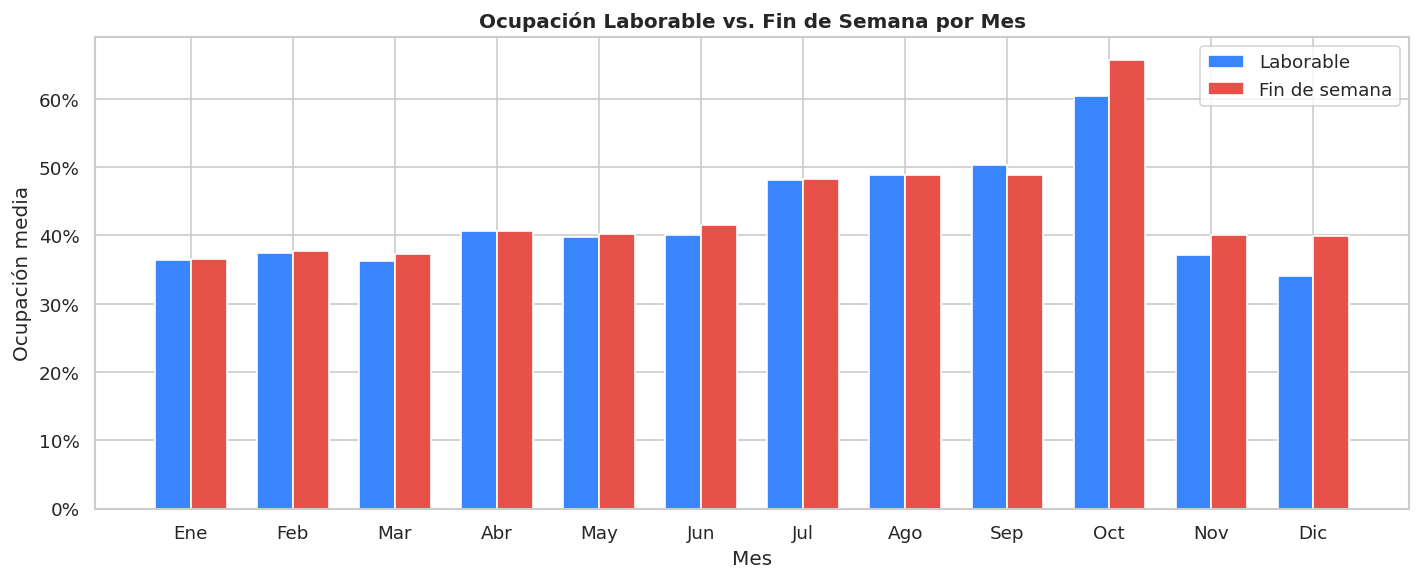

In [24]:
pivot_wknd = (calendar
              .groupby(['month', 'is_weekend'])['booked']
              .mean()
              .unstack('is_weekend')
              .rename(columns={0: 'Laborable', 1: 'Fin de semana'}))
pivot_wknd.index = month_labels[:len(pivot_wknd)]

x = np.arange(len(pivot_wknd))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, pivot_wknd['Laborable'],    width, label='Laborable',    color=BLUE,  edgecolor='white')
ax.bar(x + width/2, pivot_wknd['Fin de semana'], width, label='Fin de semana', color=ACCENT, edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(pivot_wknd.index)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_title('Ocupación Laborable vs. Fin de Semana por Mes', fontweight='bold')
ax.set_xlabel('Mes'); ax.set_ylabel('Ocupación media')
ax.legend()
plt.tight_layout()
plt.show()

In [25]:
print('Diferencia porcentual FdS - Laborable por mes:')
diff = (pivot_wknd['Fin de semana'] - pivot_wknd['Laborable'])
print(diff.apply(lambda x: f'{x:+.1%}').to_string())

Diferencia porcentual FdS - Laborable por mes:
Ene    +0.1%
Feb    +0.3%
Mar    +1.0%
Abr    -0.1%
May    +0.4%
Jun    +1.4%
Jul    +0.1%
Ago    +0.1%
Sep    -1.4%
Oct    +5.3%
Nov    +3.0%
Dic    +6.0%


El gráfico confirma visualmente lo que el test t ya anticipaba, la diferencia entre laborables y fin de semana es mínima en la mayoría de los meses. Las barras azul y roja son prácticamente indistinguibles de enero a septiembre, con diferencias que no superan el 1,4 puntos porcentuales en ningún caso.

Sin embargo, los datos de diferencia porcentual revelan un patrón estacional muy interesante, el efecto fin de semana emerge únicamente en otoño. Octubre (+5,3%), noviembre (+3,0%) y diciembre (+6,0%) son los únicos meses donde el fin de semana genera una ventaja apreciable sobre los laborables. Septiembre, curiosamente, es el único mes con diferencia negativa relevante (-1,4%), lo que sugiere que en plena temporada alta los laborables se comportan igual o mejor que el fin de semana.

Esto refuerza una conclusión ya apuntada anteriormente, en verano Málaga funciona como destino de estancia larga, donde el día de llegada importa poco. En cambio, en otoño e invierno el perfil del viajero cambia hacia escapadas cortas de fin de semana, haciendo que el sábado y el domingo ganen protagonismo relativo. Para un propietario, esto implica que aplicar precios diferenciados por fin de semana solo tiene sentido real en los meses de octubre a diciembre.

### 2.9 Detección de anomalias y outliers.

In [26]:
# Días con ocupación anormalmente baja (posibles problemas de datos)
listing_count_per_day = calendar.groupby('date')['listing_id'].nunique()
expected_listings = listing_count_per_day.median()

anomalous_days = listing_count_per_day[listing_count_per_day < 0.5 * expected_listings]
print(f'Listings activos esperados (mediana): {expected_listings:.0f}')
print(f'Días con < 50% de listings activos: {len(anomalous_days)}')
if len(anomalous_days) > 0:
    print(anomalous_days.head(10))

# Outliers en minimum_nights (Z-score)
z_scores = np.abs(stats.zscore(calendar['minimum_nights']))
outliers_mn = calendar[z_scores > 3]
print(f'\nOutliers en minimum_nights (|z|>3): {len(outliers_mn):,}')
print(f'Rango de outliers: {outliers_mn["minimum_nights"].min()} – {outliers_mn["minimum_nights"].max()} noches')

Listings activos esperados (mediana): 9714
Días con < 50% de listings activos: 0

Outliers en minimum_nights (|z|>3): 67,014
Rango de outliers: 58 – 500 noches


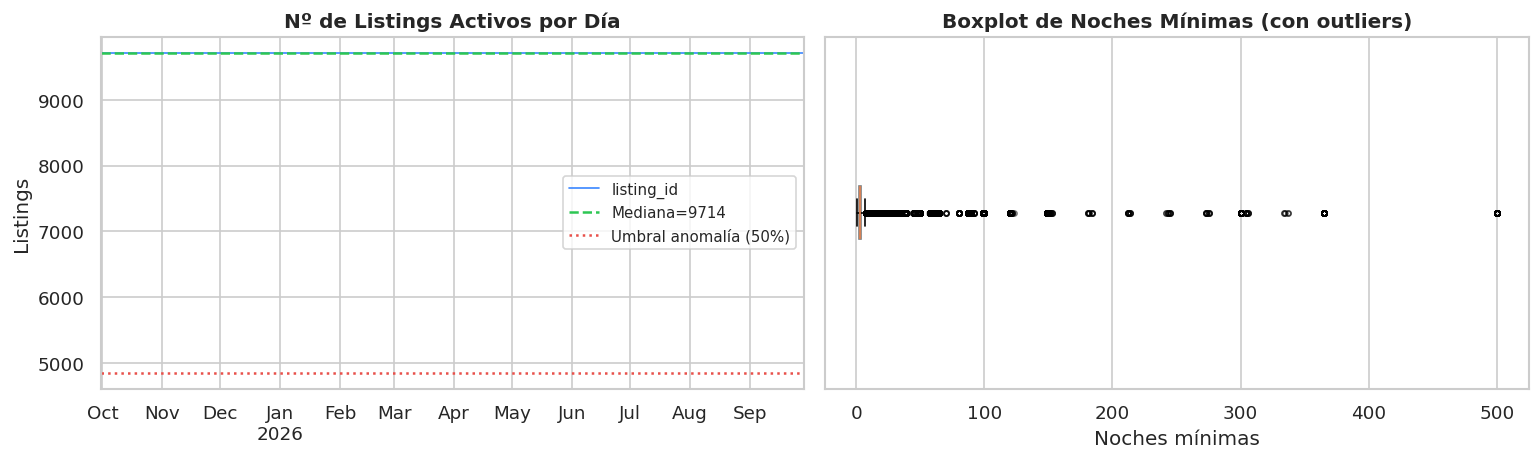

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Listings activos por día
listing_count_per_day.plot(ax=axes[0], color=BLUE, lw=1)
axes[0].axhline(expected_listings, color=GREEN, linestyle='--', lw=1.5, label=f'Mediana={expected_listings:.0f}')
axes[0].axhline(0.5*expected_listings, color=ACCENT, linestyle=':', lw=1.5, label='Umbral anomalía (50%)')
axes[0].set_title('Nº de Listings Activos por Día', fontweight='bold')
axes[0].set_xlabel(''); axes[0].set_ylabel('Listings')
axes[0].legend(fontsize=9)

# Boxplot de minimum_nights con outliers marcados
axes[1].boxplot(calendar['minimum_nights'], vert=False, patch_artist=True,
                boxprops=dict(facecolor=BLUE, alpha=0.5),
                flierprops=dict(marker='.', color=ACCENT, alpha=0.3))
axes[1].set_title('Boxplot de Noches Mínimas (con outliers)', fontweight='bold')
axes[1].set_xlabel('Noches mínimas')
axes[1].set_yticks([])

plt.tight_layout()
plt.show()

**Plot**

El gráfico de listings activos transmite un mensaje inequívoco y es que el mercado de Airbnb en Málaga es extraordinariamente estable. La línea de listings activos se mantiene pegada a la mediana de 9.714 durante todo el año, sin ninguna caída significativa, y el dato lo confirma numéricamente viendo 0 días registran menos del 50% de listings activos. El umbral de anomalía (línea roja punteada en ~4.857) nunca se alcanza en ningún momento del período analizado.

Esto tiene una implicación metodológica importante, debido a que los datos de ocupación analizados a lo largo de este informe son fiables y comparables entre meses, ya que la oferta disponible no fluctúa de forma que pueda distorsionar las métricas.

**Boxplot**

El boxplot con outliers visible completa el análisis de noches mínimas con toda su crudeza. La caja central es tan estrecha que apenas se aprecia —concentrada entre 1 y 7 noches— mientras que la nube de puntos se extiende hasta las 500 noches, con 67.014 registros clasificados como outliers estadísticos (|z|>3), todos ellos entre 58 y 500 noches.

Estos valores extremos no son simplemente ruido, ya que representan un segmento de alojamientos orientados al alquiler de media y larga duración que convive dentro de la plataforma con el mercado vacacional tradicional. Su presencia infla artificialmente la media e introduce ruido en cualquier análisis agregado, por lo que cualquier conclusión sobre el mercado vacacional de Málaga debe construirse filtrando estos outliers o tratándolos como un segmento separado.

<Axes: >

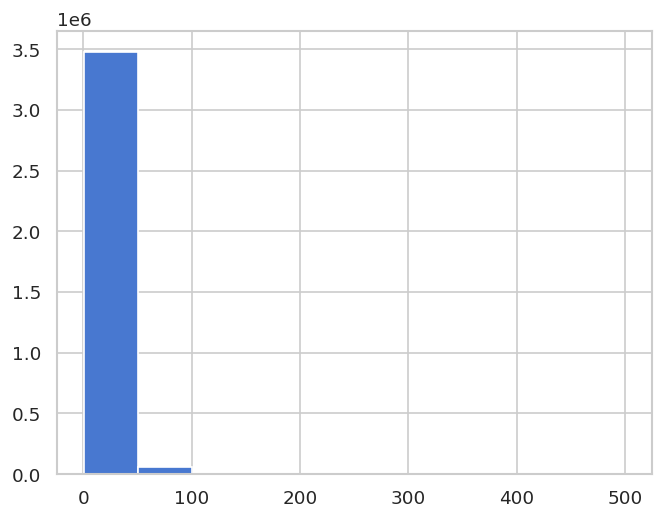

In [28]:
calendar['minimum_nights'].hist()

<Axes: >

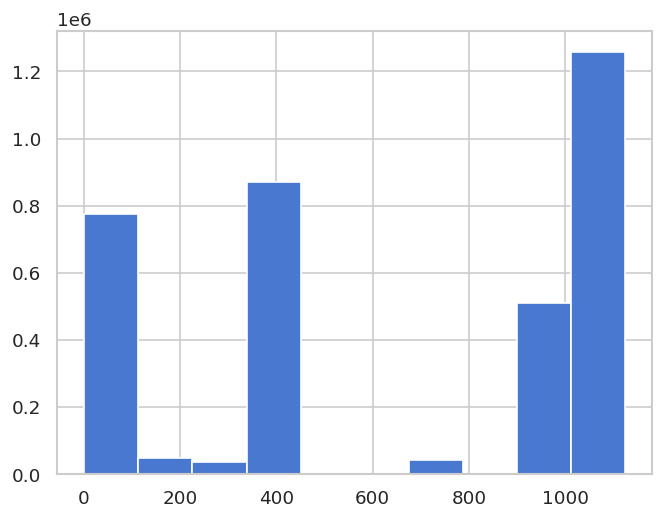

In [29]:
calendar['maximum_nights'].hist()

In [34]:
changes = calendar.groupby("listing_id")[["minimum_nights", "maximum_nights"]].nunique()

(changes > 1).sum()

minimum_nights    5797
maximum_nights    1171
dtype: int64

In [35]:
changes

,minimum_nights,maximum_nights
listing_id,,
96033,1,1
166473,1,1
330760,1,1
340024,1,1
358541,1,1
...,...,...
1518599566381530125,1,1
1518757284222557214,1,1
1518872385705241311,1,28


In [36]:
changes["min_changes"] = calendar.groupby("listing_id")["minimum_nights"].nunique()
changes["max_changes"] = calendar.groupby("listing_id")["maximum_nights"].nunique()

In [37]:
changes["min_changes"].value_counts().sort_index()

min_changes
1     3917
2     2290
3     1531
4     1170
5      578
6      154
7       53
8        6
9        2
10      12
11       1
Name: count, dtype: int64

In [38]:
changes["max_changes"].value_counts().sort_index()

max_changes
1      8543
2       319
3        33
4         7
5        10
       ... 
89        2
93        1
95        1
123       1
343       1
Name: count, Length: 67, dtype: int64

In [39]:
calendar["date"] = pd.to_datetime(calendar["date"])
calendar["month"] = calendar["date"].dt.to_period("M")

monthly = calendar.groupby(["month", "listing_id"])["minimum_nights"].nunique().reset_index()

monthly_changes = monthly.groupby("month")["minimum_nights"].apply(lambda x: (x > 1).sum())

<Axes: xlabel='month'>

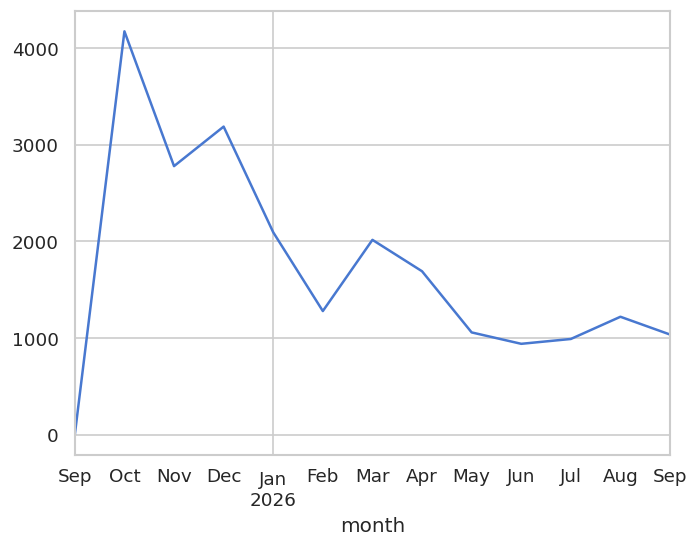

In [40]:
monthly_changes.plot()

In [41]:
calendar = calendar.sort_values(["listing_id", "date"])

calendar["min_changed"] = calendar.groupby("listing_id")["minimum_nights"].diff().ne(0)
calendar["max_changed"] = calendar.groupby("listing_id")["maximum_nights"].diff().ne(0)

In [43]:
print(calendar["min_changed"].sum())
print(calendar["max_changed"].sum())

130079
78783


In [45]:
summary = calendar.groupby("listing_id").agg({
    "minimum_nights": "nunique",
    "maximum_nights": "nunique"
})

summary.describe()

,minimum_nights,maximum_nights
count,9714.000000,9714.000000
mean,2.280420,3.762508
std,1.417563,10.289704
min,1.000000,1.000000
25%,1.000000,1.000000
50%,2.000000,1.000000
75%,3.000000,1.000000
max,11.000000,343.000000
